In [1]:
from pathlib import Path
import json
import os
import sqlite3

from dotenv import load_dotenv
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    mean_absolute_error,
    precision_score,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle, resample

load_dotenv()


True

In [2]:
current_dir = Path.cwd()
project_root_dir = current_dir.parent

db_path = project_root_dir / Path(
    os.getenv(
        "DATABASE_PATH"
    )
)
csv_path = project_root_dir / "water_potability.csv"
metrics_path = project_root_dir / "metrics/validation_metrics.json"
query = "SELECT * FROM water_potability"

if not db_path.exists():
    db_path.parent.mkdir(parents=True, exist_ok=True)
    df_csv = pd.read_csv(csv_path)
    with sqlite3.connect(db_path) as connection:
        df_csv.to_sql("water_potability", connection, if_exists="replace", index=False)

with sqlite3.connect(db_path) as connection:
    df = pd.read_sql_query(query, connection)

print(df.shape)
df.head()


(3276, 10)


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [3]:
df.describe()


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [4]:
missing_counts = df.isna().sum().sort_values(ascending=False)
duplicate_count = int(df.duplicated().sum())

missing_summary = (
    pd.DataFrame({
        "missing_count": missing_counts
    })
    .sort_values("missing_count", ascending=False)
)

missing_summary


,missing_count
Sulfate,781
ph,491
Trihalomethanes,162
Hardness,0
Solids,0
Chloramines,0
Conductivity,0
Organic_carbon,0
Turbidity,0
Potability,0


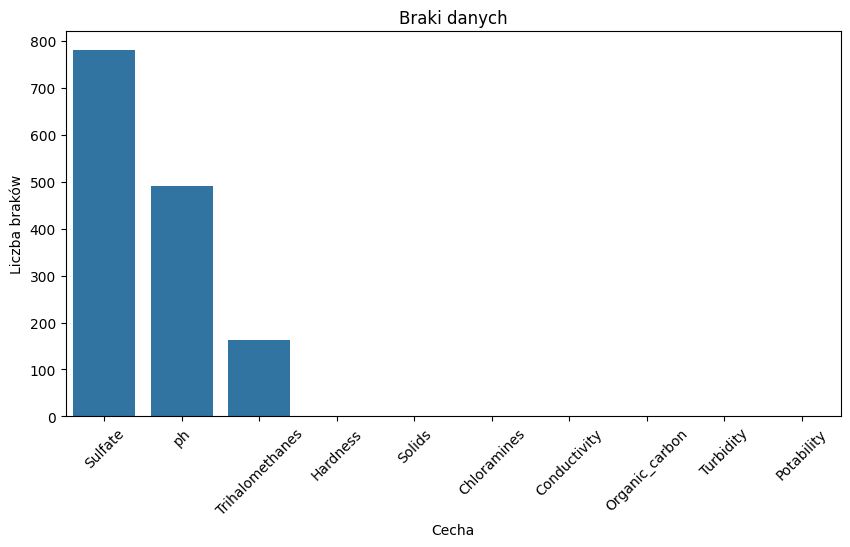

In [5]:
missing_plot = missing_summary.reset_index().rename(columns={"index": "feature"})

plt.figure(figsize=(10, 5))
sns.barplot(data=missing_plot, x="feature", y="missing_count")
plt.title("Braki danych")
plt.xlabel("Cecha")
plt.ylabel("Liczba braków")
plt.xticks(rotation=45)
plt.show()


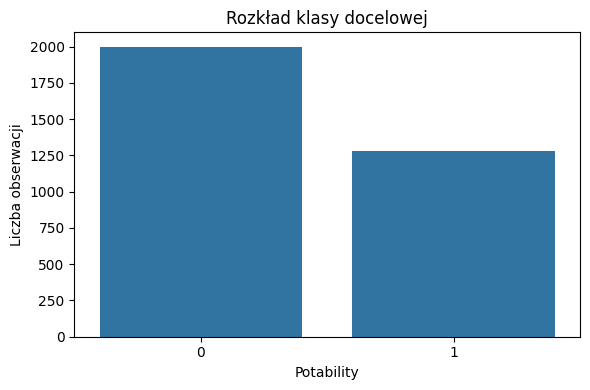

In [6]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Potability")
plt.title("Rozkład klasy docelowej")
plt.xlabel("Potability")
plt.ylabel("Liczba obserwacji")
plt.tight_layout()
plt.show()


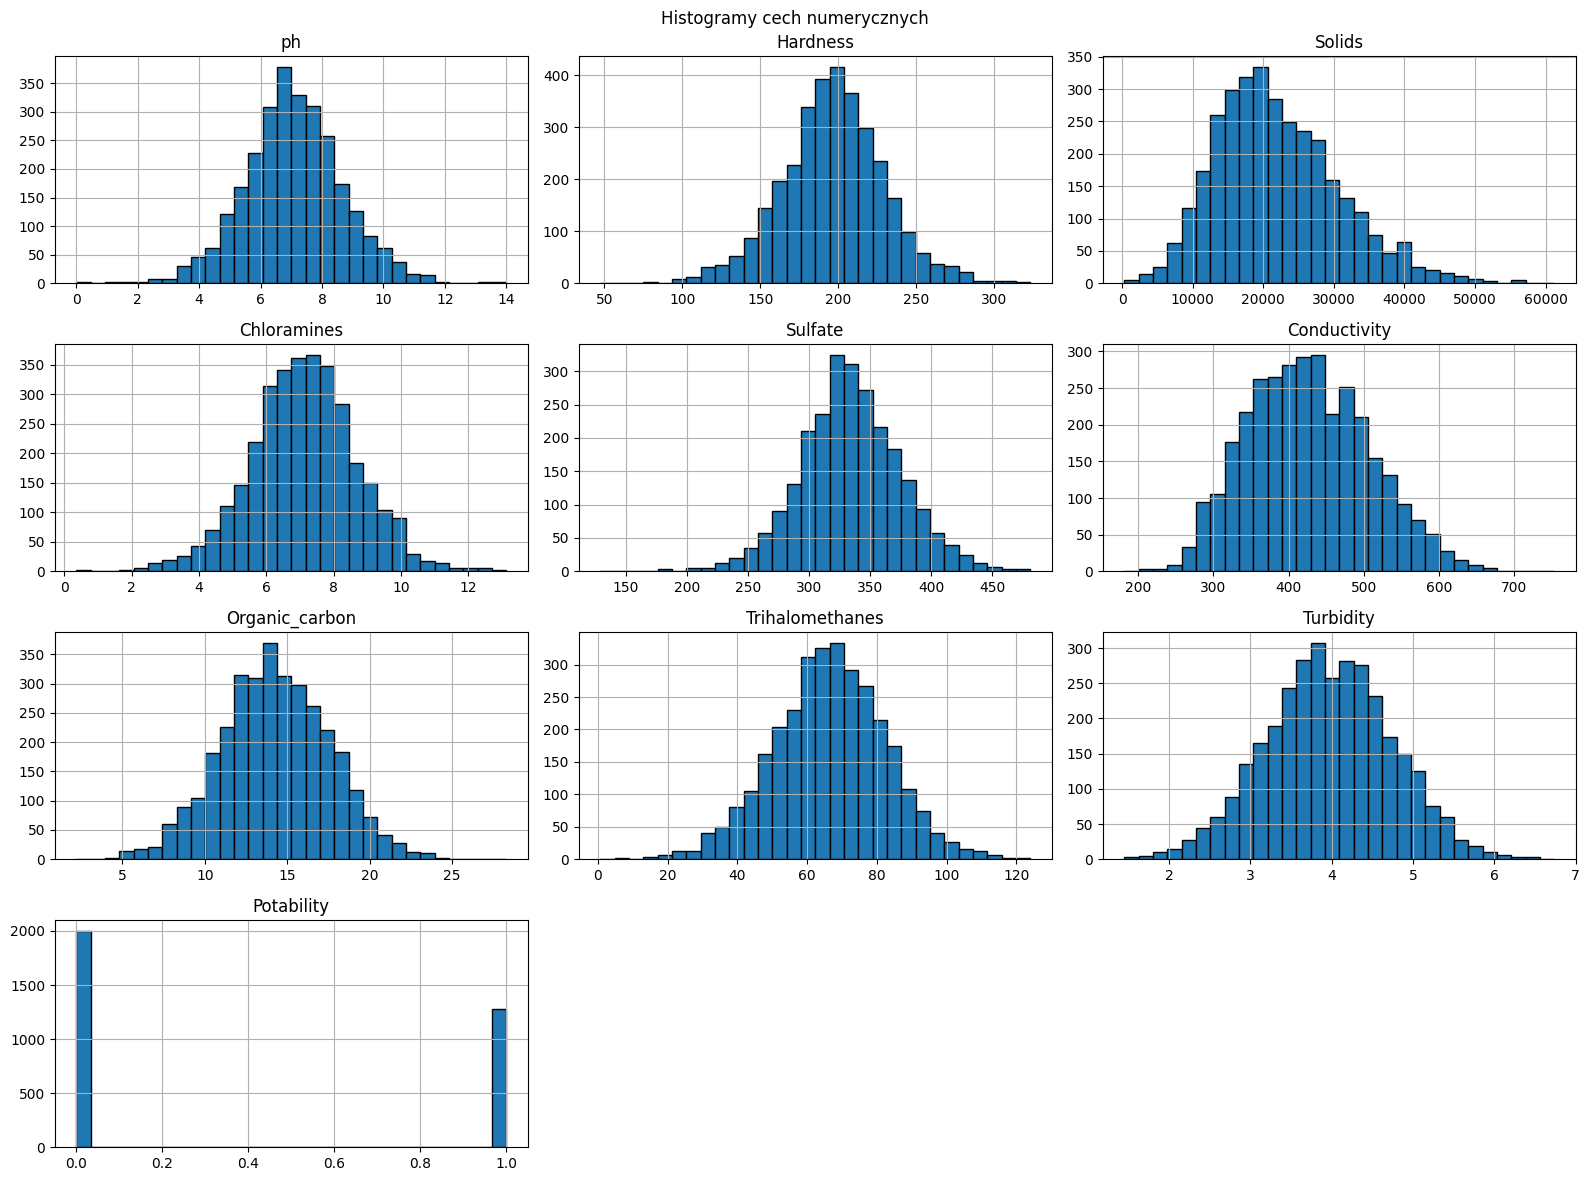

In [7]:
df.hist(figsize=(16, 12), bins=30, edgecolor="black")
plt.suptitle("Histogramy cech numerycznych")
plt.tight_layout()
plt.show()


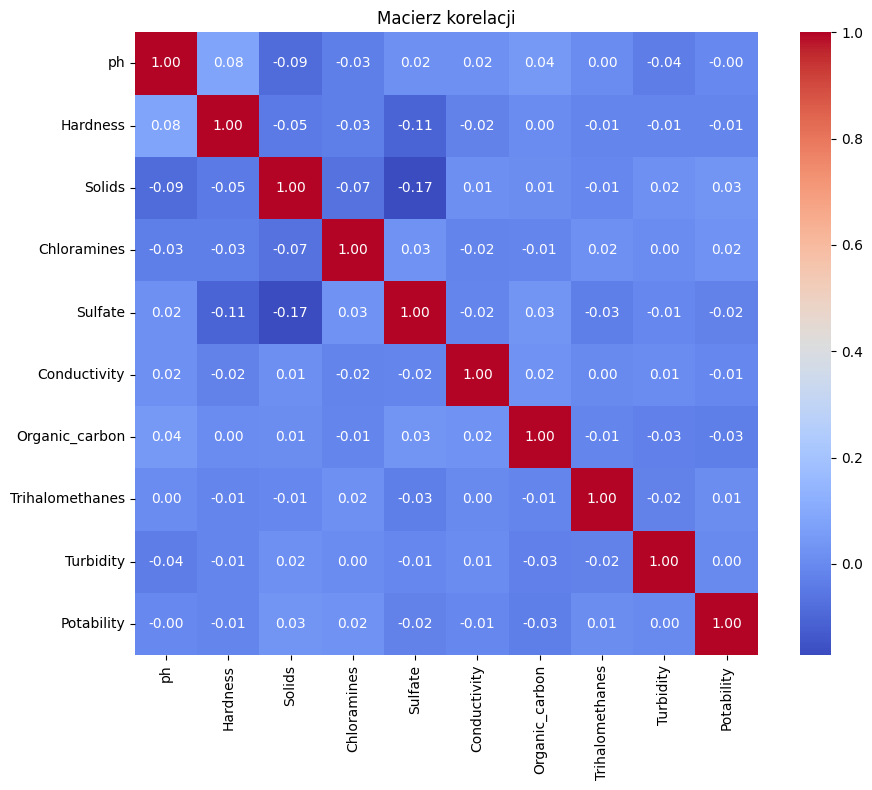

In [6]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Macierz korelacji")
plt.tight_layout()
plt.show()


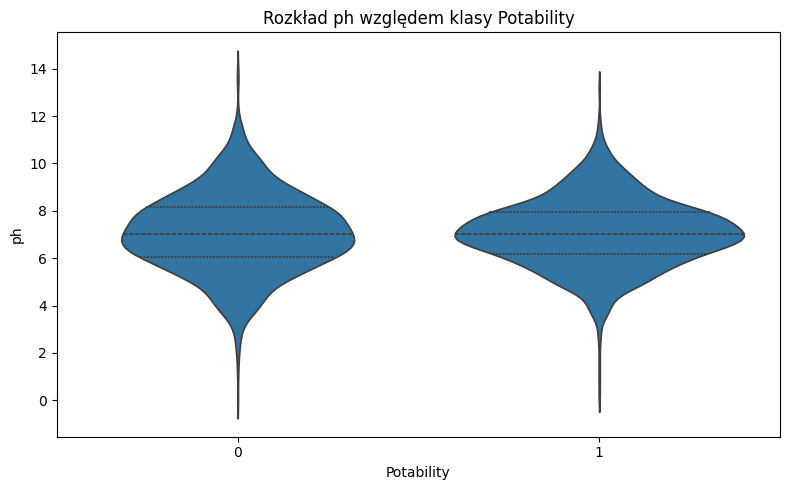

In [7]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df, x="Potability", y="ph", inner="quartile")
plt.title("Rozkład ph względem klasy Potability")
plt.xlabel("Potability")
plt.ylabel("ph")
plt.tight_layout()
plt.show()


In [ ]:
df.Potability.value_counts()

notpotable  = df[df['Potability']==0]
potable = df[df['Potability']==1]  

df_minority_upsampled = resample(potable, replace = True, n_samples = 1998) 

data = pd.concat([notpotable, df_minority_upsampled])
data = shuffle(df) 

In [11]:
df_model = df.copy()

X = df_model.drop(columns=["Potability"])
y = df_model["Potability"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp,
)

In [ ]:
baseline_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1,
            ),
        ),
    ]
)

baseline_model.fit(X_train, y_train)
val_pred = baseline_model.predict(X_val)
val_pred_proba = baseline_model.predict_proba(X_val)[:, 1]

validation_metrics = {
    "accuracy": round(float(accuracy_score(y_val, val_pred)), 4),
    "precision": round(float(precision_score(y_val, val_pred)), 4),
    "rmse": round(float(root_mean_squared_error(y_val, val_pred_proba)), 4),
    "mae": round(float(mean_absolute_error(y_val, val_pred_proba)), 4),
    "r2": round(float(r2_score(y_val, val_pred_proba)), 4)
}

pd.Series(validation_metrics, name="value").to_frame()


,value
accuracy,0.6538
precision,0.6438
rmse,0.4681
mae,0.4384
r2,0.0780


In [13]:
metrics_path.parent.mkdir(parents=True, exist_ok=True)
with metrics_path.open("w", encoding="utf-8") as file:
    json.dump(validation_metrics, file, indent=2)


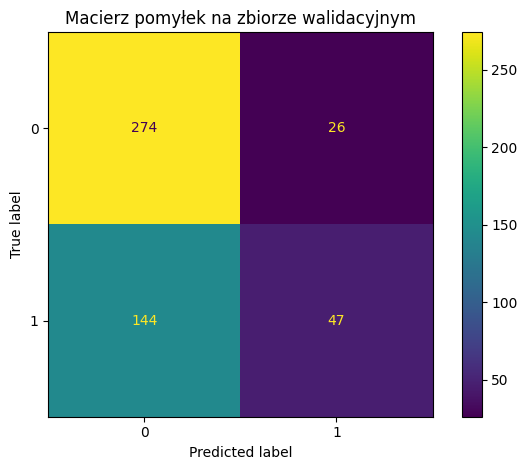

In [14]:
ConfusionMatrixDisplay.from_predictions(y_val, val_pred)
plt.title("Macierz pomyłek na zbiorze walidacyjnym")
plt.tight_layout()
plt.show()
